# Analysis & studies: running, saving, augmenting, plotting

This notebook is the end-to-end story for getting data **out** of the simulator.
A single circuit is one sample; a *study* is a parameter sweep with persisted,
re-analyzable results. There are two ways to measure observables, and you will
use both:

1. **Online**: compute observables at the end of each circuit and throw the
   tableau away. Memory-light; use it when you already know what you want.
2. **Offline (save then analyze)**: save every final tableau, then analyze it
   later. This is what makes the database *extensible*: run the expensive
   simulations once, then decide on new observables (code rate, contiguous
   distance, …) whenever you like and **merge them in without re-simulating**.

Contents:
1. Online analysis on a single circuit
2. The same analyses, offline, on a saved tableau
3. A `Study`: a persisted parameter sweep
4. **Augmenting** a study with new observables: no re-simulation
5. Plotting (auto-detects every column, including augmented ones)
6. The purification transition, start to finish

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sparsegf2.circuits import CircuitConfig, simulate
from sparsegf2.analysis import Study, analyze, plot_study, ANALYSES

print('built-in analyses:')
print(', '.join(sorted(ANALYSES)))

built-in analyses:
average_stabilizer_weight, bipartite_mutual_info, code_dimension, code_rate, contiguous_distance, entropy_profile, half_cut_entropy, ref_entropy, stabilizer_weight_spectrum, tripartite_mutual_info


## 1. Online analysis on a single circuit

Pass `analyses=[...]` to `simulate`. Each name resolves to a picture-aware
observable; the results land in `rec.analyses`. The tableau is built, measured,
read, and discarded, and nothing large is kept.

In [2]:
cfg = CircuitConfig(graph_spec='cycle', n=24, picture='purification',
                    p=0.12, depth_factor=6)
rec = simulate(cfg, sample_seed=0,
               analyses=['code_dimension', 'code_rate', 'half_cut_entropy'])
print('online analyses:', rec.analyses)
print('tableau kept?   ', rec.final_tableau is not None)   # online: no

online analyses: {'code_dimension': 0, 'code_rate': 0.0, 'half_cut_entropy': 7}
tableau kept?    False


You can also pass **your own** callable `fn(sim, spec) -> value`, and it is
treated exactly like a built-in, so a custom observable works online and offline
without any special-casing.

In [3]:
def heavy_generator_fraction(sim, spec):
    '''Fraction of stabilizer generators with weight > n/4.'''
    from sparsegf2 import generator_weights
    w = generator_weights(sim)
    return float((w > sim.n / 4).mean())

rec = simulate(cfg, sample_seed=0, analyses=['code_rate', heavy_generator_fraction])
print(rec.analyses)

{'code_rate': 0.0, 'heavy_generator_fraction': 0.28125}


## 2. The same analyses, offline, on a saved tableau

Ask `simulate` to keep the final tableau (`save_tableau=True`). Later,
`analyze(...)` runs the same named analyses on that tableau and returns the same
values, and the online and offline paths agree by construction.

In [4]:
from sparsegf2.circuits.picture import setup_picture

rec = simulate(cfg, sample_seed=0, save_tableau=True)
symp = rec.final_tableau                      # the (2N, 2N) GF(2) symplectic
print('saved tableau shape:', symp.shape)

spec = setup_picture('purification', 24)[1]   # the PictureSpec for n_system=24
offline = analyze(symp, spec, ['code_dimension', 'code_rate'])
online  = simulate(cfg, sample_seed=0,
                   analyses=['code_dimension', 'code_rate']).analyses
print('offline:', offline)
print('online :', online)
assert offline == online, 'online and offline must agree'
print('online == offline  ✓')

saved tableau shape: (96, 96)
offline: {'code_dimension': 0, 'code_rate': 0.0}
online : {'code_dimension': 0, 'code_rate': 0.0}
online == offline  ✓


## 3. A `Study`: a persisted parameter sweep

`Study.run` expands a grid of config fields × seeds, runs every cell, and writes
a directory of `rows.parquet` (keyed rows) + `tableaux.h5` (the saved tableaux)
+ `manifest.json`. Here we sweep system size `n` and measurement rate `p`,
computing the order parameter (`code_dimension`) online and saving the tableaux
for later.

In [5]:
import tempfile, os
workdir = tempfile.mkdtemp(prefix='sgf2_study_')
path = os.path.join(workdir, 'transition')

base = CircuitConfig(graph_spec='cycle', n=16, picture='purification',
                     p=0.1, depth_factor=6)
study = Study.run(path, base,
                  grid={'n': [12, 16, 24], 'p': [0.04, 0.08, 0.12, 0.16, 0.20]},
                  seeds=40, analyses=['code_dimension'], save_tableaux=True)
print(study)
print('columns:', study.analysis_columns())
study.to_pandas().head()

Study(path='/var/folders/yt/xg9kjxjs22s712kz_9hz7j4h0000gn/T/sgf2_study_cs0znpxt/transition', rows=600, tableaux=True, analyses=['code_dimension'])
columns: ['a.code_dimension']


,n,p,picture,sample_seed,total_layers,total_gates,total_measurements,gate_to_meas_ratio_expected,gate_to_meas_ratio_actual,code_dimension,ref_entropy,entropy_half_cut,runtime_total_s,a.code_dimension
0,12,0.04,purification,0,72,432,25,12.5,17.280000,6,None,5,0.002515,6
1,12,0.04,purification,1,72,432,36,12.5,12.000000,6,None,6,0.002723,6
2,12,0.04,purification,2,72,432,39,12.5,11.076923,4,None,5,0.002395,4
3,12,0.04,purification,3,72,432,33,12.5,13.090909,4,None,6,0.002144,4
4,12,0.04,purification,4,72,432,27,12.5,16.000000,6,None,5,0.001949,6


## 4. Augmenting a study with new observables

Now the payoff. Suppose we later decide we also want the **code rate** ($k/n$)
and the **contiguous distance** (the smallest contiguous region carrying logical
information). We do *not* re-run the simulations: `study.augment([...])`
reconstructs each saved tableau, computes the new observables, and merges the new
columns into `rows.parquet` keyed by cell. It only computes what's missing, so
it's cheap and idempotent.

In [6]:
study.augment(['code_rate', 'contiguous_distance'])
print('columns now:', study.analysis_columns())
study.to_pandas()[['n', 'p', 'sample_seed', 'a.code_dimension',
                   'a.code_rate', 'a.contiguous_distance']].head()

columns now: ['a.code_dimension', 'a.code_rate', 'a.contiguous_distance']


,n,p,sample_seed,a.code_dimension,a.code_rate,a.contiguous_distance
0,12,0.04,0,6,0.500000,1.0
1,12,0.04,1,6,0.500000,1.0
2,12,0.04,2,4,0.333333,2.0
3,12,0.04,3,4,0.333333,1.0
4,12,0.04,4,6,0.500000,2.0


In [7]:
# re-augmenting is a no-op (the columns already exist) -> idempotent
before = study.to_pandas().shape
study.augment(['code_rate'])
print('shape unchanged on re-augment:', before == study.to_pandas().shape)

# reopening from disk shows the augmented columns persisted
reopened = Study.open(path)
print('persisted columns:', reopened.analysis_columns())

shape unchanged on re-augment: True
persisted columns: ['a.code_dimension', 'a.code_rate', 'a.contiguous_distance']


## 5. Plotting

`plot_study` auto-detects every numeric observable column and draws one panel per
observable, the order parameter vs `p`, one curve per system size `n`. Because
it auto-detects, the **same call** now includes the columns we just augmented in,
with no edits.

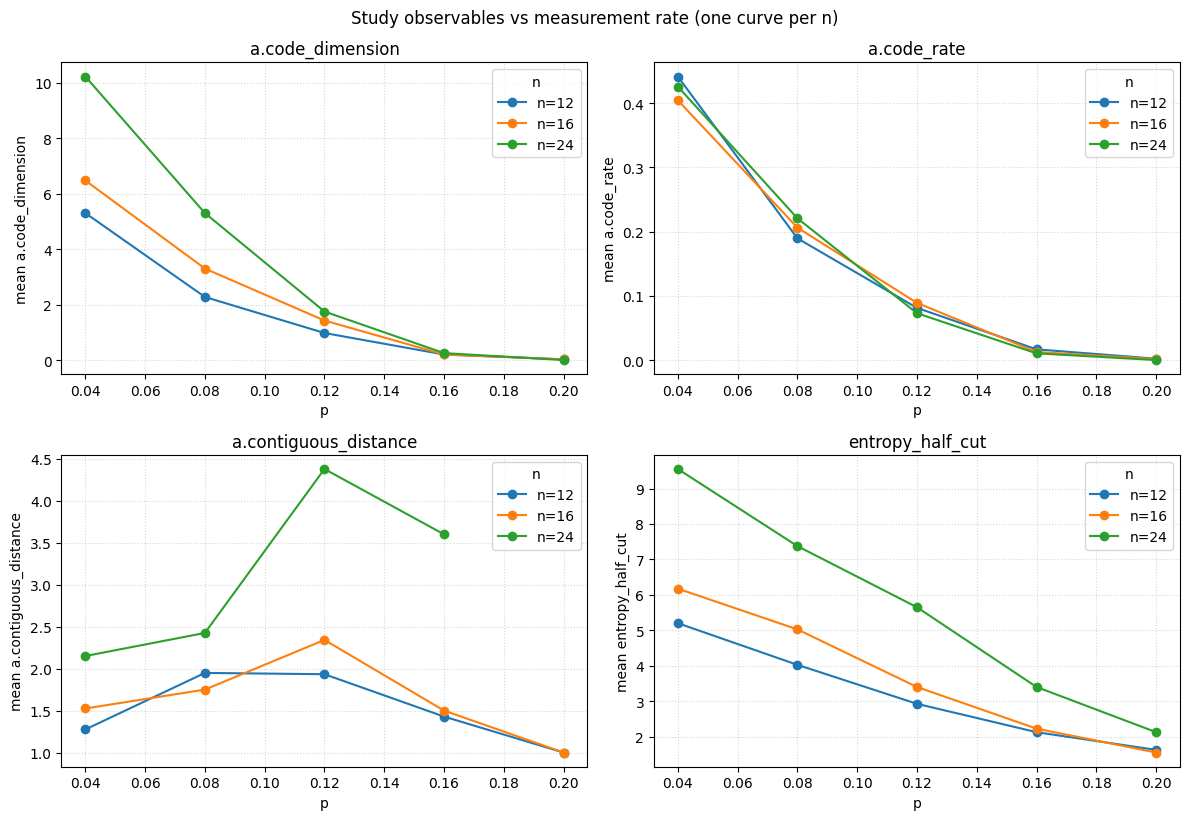

In [8]:
fig = plot_study(study)
fig.suptitle('Study observables vs measurement rate (one curve per n)', y=1.02)
plt.show()

The command-line script does the same and is the thing you actually run after a
big sweep finishes:

```sh
python scripts/plot_study.py runs/transition --out transition.png
python scripts/plot_study.py runs/transition --list      # list plottable columns
```

## 6. The purification transition, start to finish

The purification picture's order parameter is the **code dimension**
$k = S(\text{system})$, the number of system qubits still entangled with the
reference. It starts at $k = n$ (fresh Bell purification) and falls toward $0$ as
measurements purify the system. Plotting $\langle k \rangle / n$ (the code rate)
against $p$ for several $n$ shows the transition: a family of curves that steepen
and cross as $n$ grows.

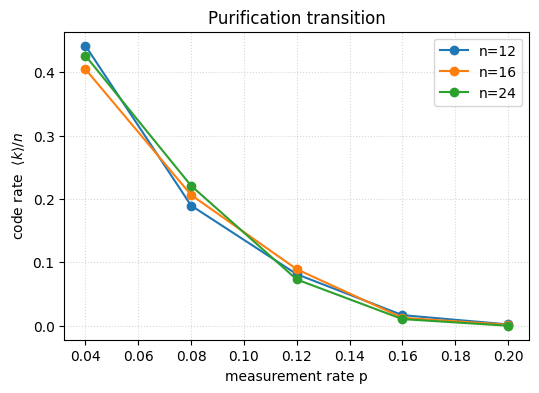

In [9]:
df = study.to_pandas()
fig, ax = plt.subplots(figsize=(6, 4))
for n, sub in df.groupby('n'):
    g = sub.groupby('p')['a.code_rate'].mean()
    ax.plot(g.index, g.to_numpy(), 'o-', label=f'n={n}')
ax.set_xlabel('measurement rate p')
ax.set_ylabel(r'code rate  $\langle k \rangle / n$')
ax.set_title('Purification transition')
ax.legend(); ax.grid(True, ls=':', alpha=0.5)
plt.show()

### Tracking the transition layer by layer

For the *dynamical* purification transition you want the order parameter at every
layer, not just at the end. Pass `record_time_series=True` (and optionally
`until_purified=True` to stop early once the system purifies). `rec.time_series`
is then the per-layer code dimension.

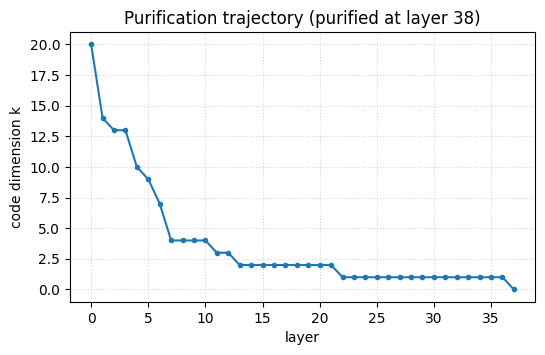

In [10]:
tcfg = CircuitConfig(graph_spec='cycle', n=24, picture='purification',
                     p=0.16, depth_factor=10,
                     depth_mode='until_purified', record_time_series=True)
trec = simulate(tcfg, sample_seed=1)
ts = trec.time_series
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(len(ts)), ts, '-o', ms=3)
ax.set_xlabel('layer'); ax.set_ylabel('code dimension k')
ax.set_title(f'Purification trajectory (purified at layer {trec.purified_at_layer})')
ax.grid(True, ls=':', alpha=0.5)
plt.show()

## Summary

- **Online** (`simulate(..., analyses=[...])`) computes observables and discards
  the tableau, memory-light; use when the observables are known up front.
- **Offline** (`save_tableau=True` / `Study.run(save_tableaux=True)`) keeps the
  tableaux so you can analyze them later; online and offline agree exactly.
- **`Study`** persists a sweep as keyed rows + tableaux + manifest.
- **`study.augment([...])`** adds new observables to saved tableaux and merges
  them in keyed by cell: no re-simulation, idempotent.
- **`plot_study`** auto-detects every observable column, so augmented data plots
  with no code changes.

Next: build your own study by editing the grid in step 3, or wire a custom
`fn(sim, spec)` analysis (step 1) into `Study.run(analyses=[...])`.